# MIRepNet on BNCI2014001 (BCI IV-2a) - full LOSO + K-min calibration

Same protocol idea as `mirepnet_kmin.ipynb`, but on **BNCI2014001** (BCI
Competition IV dataset 2a) instead of EEGMMI, and with a **full
leave-one-subject-out** sweep: the dataset has only 9 subjects, so each subject
is held out once (source = the other 8) and gets the K-trial calibration sweep on
its own fixed eval set. Two heads on the frozen 256-d MIRepNet feature: a linear
probe and the 2-stage convex-NN head.

Unlike EEGMMI, **BNCI2014001 is *not* MIRepNet's `PHYSIONETMI` pretraining
source**, so this is a more honest cross-dataset evaluation (it is also the
"<30 trials/class" few-shot regime MIRepNet targets - hence K up to 30 here).

## Loader: MOABB

The repo's dataset names (`BNCI2014001`, `BNCI2014004`, `AlexMI`, `Lee`, ...) are
exactly MOABB dataset classes, so we load via MOABB's `MotorImagery` paradigm -
it handles download, epoching, band-pass and resampling uniformly.

## BNCI2014001 -> MIRepNet input format (verified against the data)

| field | value |
|---|---|
| subjects / classes | 9 subjects, 4 classes (left_hand, right_hand, feet, tongue), **144 trials/class/subject** (2 sessions x 288) |
| native montage | **22 EEG channels** = `BNCI2014001_chn_names` (Fz, FC3..FC4, C5..C6, CP3..CP4, P1/Pz/P2, POz) |
| band-pass / resample | **8-30 Hz**, **250 Hz** (`MotorImagery(fmin=8, fmax=30, resample=250)`) |
| window | dataset interval **[2, 6] s** -> 1001 samples, trimmed to **1000** (4 s) |
| distribution alignment | **Euclidean Alignment** on the native 22 ch, per subject |
| channel template | EA'd 22 ch -> **45-ch template** via inverse-distance interpolation (`pad_missing_channels_diff`); 21 of 45 are present, 24 are interpolated |
| model / feature | MIRepNet (emb 256, depth 6); **256-d** mean-pooled `pooled` feature |

The EA-then-interpolate order matches MIRepNet's `process_and_replace_loader`.


## 0. Config

In [1]:
from __future__ import annotations

import sys, os, json, time, warnings
from pathlib import Path

import numpy as np
import torch
warnings.filterwarnings("ignore")

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
CLD_DIR = REPO_ROOT / "vendor" / "CLD"
MIREPNET_VENDOR = REPO_ROOT / "vendor" / "MIRepNet"
FEAT_CACHE_DIR = REPO_ROOT / "data" / "cache" / "mirepnet_bnci2014001_feats"
assert CLD_DIR.exists(), f"missing CLD vendor dir: {CLD_DIR}"
assert (MIREPNET_VENDOR / "mirepnet_model.py").exists() and (MIREPNET_VENDOR / "mirepnet_align.py").exists()

# --- protocol ---
# Full LOSO: every subject is held out once. Per held-out subject, a K-per-class
# calibration sweep on a fixed eval set (constant across K, drawn disjoint from
# the calibration pool). BNCI2014001 has ~144 trials/class, so we reserve a
# generous eval set and probe K up to 30 (MIRepNet's "<30 trials/class" regime).
K_BUDGETS      = (0, 1, 2, 5, 10, 20, 30)   # trials per class; K=0 = pure LOSO
EVAL_PER_CLASS = 40                          # fixed held-out eval trials per class
SEED           = 0

# --- MIRepNet preprocessing spec ---
N_CLASSES    = 4
TARGET_FS    = 250
BANDPASS     = (8.0, 30.0)
TRIAL_SAMPLES = 1000                         # 4 s at 250 Hz (interval [2,6] -> trim 1001 to 1000)
FEATURE_DIM  = 256
N_CHANNELS   = 45                            # MIRepNet template (after interpolation)
LABEL_MAP = {"left_hand": 0, "right_hand": 1, "feet": 2, "tongue": 3}
CLASS_NAMES = ("left_hand", "right_hand", "feet", "tongue")

MIREPNET_DEVICE = "cpu"   # 5.2M params; CPU is fine and avoids accelerator contention

# --- ConvexNN head hparams (same as the REVE/EEGMMI notebooks) ---
CVX_N_NEURONS  = 64
CVX_BETA       = 1.0e-3
CVX_RHO        = 0.1
CVX_ADMM_ITERS = 8
CVX_PCG_ITERS  = 32
CVX_RANK       = 20
STAGE2_ADMM_ITERS = 4
STAGE2_TARGET_MASS = 0.35
STAGE2_WARM_START_DUAL = False

# --- Linear probe hparams ---
LINPROBE_C = 1.0
LINPROBE_MAX_ITER = 2000
LINPROBE_TARGET_MASS = STAGE2_TARGET_MASS

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"torch device={DEVICE}  mirepnet_device={MIREPNET_DEVICE}  |  repo={REPO_ROOT}")


torch device=mps  mirepnet_device=cpu  |  repo=/Users/williamtan/Projects/cs229/etm_clf


## 1. Load BNCI2014001 via MOABB + MIRepNet channel template

In [2]:
import moabb
from moabb.paradigms import MotorImagery
try:
    from moabb.datasets import BNCI2014_001 as _BNCI
except Exception:
    from moabb.datasets import BNCI2014001 as _BNCI

if str(MIREPNET_VENDOR) not in sys.path:
    sys.path.insert(0, str(MIREPNET_VENDOR))
from mirepnet_align import use_channels_names, BNCI2014001_chn_names, channel_positions, EA, pad_missing_channels_diff

DATASET = _BNCI()
PARADIGM = MotorImagery(n_classes=N_CLASSES, fmin=BANDPASS[0], fmax=BANDPASS[1], resample=float(TARGET_FS))
SUBJECTS = list(DATASET.subject_list)
print(f"dataset={DATASET.code}  subjects={SUBJECTS}  interval={DATASET.interval}")
print(f"template channels needing interpolation: "
      f"{sum(1 for c in use_channels_names if c not in BNCI2014001_chn_names)}/45")

def get_subject_raw(subj: int):
    """Return (X_native (n,22,1000), y_int (n,), native_ch_names) for one subject."""
    epochs, y, _meta = PARADIGM.get_data(dataset=DATASET, subjects=[subj], return_epochs=True)
    native = [c.upper() for c in epochs.ch_names]
    X = epochs.get_data(copy=False).astype(np.float32)[:, :, :TRIAL_SAMPLES]
    yi = np.asarray([LABEL_MAP[str(v)] for v in y], dtype=np.int64)
    return X, yi, native


Choosing from all possible events


dataset=BNCI2014-001  subjects=[1, 2, 3, 4, 5, 6, 7, 8, 9]  interval=[2, 6]
template channels needing interpolation: 24/45


## 2. MIRepNet feature extractor (EA on 22 ch -> interpolate to 45 -> 256-d)

In [3]:
from mirepnet_model import mlm_mask
from huggingface_hub import hf_hub_download

def build_mirepnet():
    model = mlm_mask(emb_size=256, depth=6, n_classes=N_CLASSES, pretrainmode=False)
    try:
        ckpt = hf_hub_download(repo_id="starself/MIRepNet", filename="MIRepNet.pth")
        sd = torch.load(ckpt, map_location="cpu", weights_only=True)
        msd = model.state_dict()
        overlap = {k: v for k, v in sd.items() if k in msd and v.shape == msd[k].shape}
        res = model.load_state_dict(overlap, strict=False)
        print(f"MIRepNet: loaded {len(overlap)}/{len(sd)} pretrained tensors (missing={res.missing_keys})")
    except Exception as e:
        warnings.warn(f"MIRepNet pretrained load failed ({type(e).__name__}: {e}); using random init.")
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model.to(MIREPNET_DEVICE)

@torch.no_grad()
def encode_subject(model, X_native: np.ndarray, native: list[str], batch_size: int = 64) -> np.ndarray:
    """EA the native 22-ch trials (per subject), interpolate to the 45-ch template,
    then take MIRepNet's 256-d pooled feature."""
    Xea = EA(X_native.astype(np.float64))                                  # (n, 22, 1000)
    Xt = pad_missing_channels_diff(Xea, use_channels_names, native).astype(np.float32)  # (n, 45, 1000)
    feats = []
    for i in range(0, len(Xt), batch_size):
        xb = torch.from_numpy(Xt[i:i + batch_size]).to(MIREPNET_DEVICE)
        pooled, _ = model(xb)
        feats.append(pooled.detach().cpu().numpy().astype(np.float32))
    return np.concatenate(feats, axis=0) if feats else np.zeros((0, FEATURE_DIM), np.float32)


## 3. Convex two-layer ReLU MLP head with warm-startable ADMM (backbone-agnostic)

In [4]:
if str(CLD_DIR) not in sys.path:
    sys.path.insert(0, str(CLD_DIR))
import jax
import jax.numpy as jnp
from cld.models.cvx_relu_mlp import CVX_ReLU_MLP
from cld.optimizers.pcg import pcg
from cld.preconditioner.nystrom import Nys_Precond, rand_nys_appx
from cld.utils.proximal_utils import batch_proxl2_tensor
from sklearn.preprocessing import StandardScaler

def admm_warm(model, admm_params, u_init=None, v_init=None, lam_init=None):
    """Inlined ADMM with optional warm-start on (u, v, lam).

    (s, nu) are always re-zeroed since their shape depends on n_samples.
    Stores final (u, v, s, lam, nu, theta1, theta2) on the model.
    """
    rank        = admm_params["rank"]
    beta        = admm_params["beta"]
    gamma_ratio = admm_params["gamma_ratio"]
    admm_iters  = admm_params["admm_iters"]
    pcg_iters   = admm_params["pcg_iters"]

    n, d = model.X.shape
    Y = jax.nn.one_hot(model.y, model.n_classes)

    weight_shape = (model.n_classes, 2, d, model.P_S)
    sample_shape = (model.n_classes, 2, n, model.P_S)

    u   = jnp.asarray(u_init)   if u_init   is not None else jnp.zeros(weight_shape)
    v   = jnp.asarray(v_init)   if v_init   is not None else jnp.zeros(weight_shape)
    lam = jnp.asarray(lam_init) if lam_init is not None else jnp.zeros(weight_shape)
    s   = jnp.zeros(sample_shape)
    nu  = jnp.zeros(sample_shape)

    # Sanity: warm-start tensors must match the new feature/neuron dims.
    for name, arr in (("u_init", u), ("v_init", v), ("lam_init", lam)):
        if arr.shape != weight_shape:
            raise ValueError(f"{name} shape {arr.shape} != expected {weight_shape}")

    U, S, model.seed = rand_nys_appx(model, rank, model.seed)
    Mnys = Nys_Precond(U, S, d, model.rho, model.P_S)
    b_1 = model.batch_rmatvec_F(Y.T) / model.rho

    for _ in range(admm_iters):
        # u update via PCG
        b = b_1 + v - lam + model.batch_rmatvec_G(s - nu)
        u, _, _ = pcg(b, model, Mnys, pcg_iters)
        # v update (group-lasso prox)
        v = v.at[:, 0, :].set(batch_proxl2_tensor(u[:, 0, :] + lam[:, 0, :], beta=beta, gamma=1 / model.rho))
        v = v.at[:, 1, :].set(batch_proxl2_tensor(u[:, 1, :] + lam[:, 1, :], beta=beta, gamma=1 / model.rho))
        # s update (ReLU-cone projection)
        Gu = model.batch_matvec_G(u)
        s = jax.nn.relu(Gu + nu)
        # dual updates
        lam += (u - v) * gamma_ratio
        nu  += (Gu - s) * gamma_ratio

    model.u, model.v, model.s, model.lam, model.nu = u, v, s, lam, nu
    W1, w2 = model.get_ncvx_weights(v)
    model.theta1, model.theta2 = W1, w2
    return u, v, s, lam, nu

def fit_stage1_source(X: np.ndarray, y: np.ndarray, n_classes: int = 4, beta: float = CVX_BETA):
    """Stage 1: cold ADMM on the source pool."""
    scaler = StandardScaler().fit(X)
    Xs = scaler.transform(X).astype(np.float32)
    m = CVX_ReLU_MLP(
        jnp.asarray(Xs), jnp.asarray(y.astype(np.int32)),
        n_classes=n_classes, P_S=CVX_N_NEURONS,
        beta=beta, rho=CVX_RHO,
        seed=jax.random.PRNGKey(SEED),
    )
    m.init_model()
    admm_warm(
        m,
        dict(rank=CVX_RANK, beta=beta, gamma_ratio=1.0,
             admm_iters=CVX_ADMM_ITERS, pcg_iters=CVX_PCG_ITERS, check_opt=False),
    )
    return m, scaler

def fit_stage2_target_only_warm(
    Xc: np.ndarray,
    yc: np.ndarray,
    src_model,
    src_scaler,
    n_classes: int = 4,
    beta: float = CVX_BETA,
):
    """Diagnostic only: solve the new convex problem on calibration trials alone.

    This is the experiment that produced the early-K accuracy drop. Warm start is
    only an ADMM initializer; it is not a source prior once the solve moves.
    """
    Xc_s = src_scaler.transform(Xc.astype(np.float32))
    m = CVX_ReLU_MLP(
        jnp.asarray(Xc_s), jnp.asarray(yc.astype(np.int32)),
        n_classes=n_classes, P_S=CVX_N_NEURONS,
        beta=beta, rho=CVX_RHO,
        seed=jax.random.PRNGKey(SEED),  # same random hyperplanes
    )
    m.init_model()
    admm_warm(
        m,
        dict(rank=CVX_RANK, beta=beta, gamma_ratio=1.0,
             admm_iters=STAGE2_ADMM_ITERS, pcg_iters=CVX_PCG_ITERS, check_opt=False),
        u_init=src_model.u,
        v_init=src_model.v,
        lam_init=src_model.lam if STAGE2_WARM_START_DUAL else None,
    )
    return m

def calibration_repeat_count(n_src: int, n_calib: int, target_mass: float = STAGE2_TARGET_MASS) -> int:
    """Integer row-repeat approximation to a source/target weighted loss."""
    if n_calib <= 0:
        return 0
    target_mass = float(np.clip(target_mass, 1.0e-3, 0.95))
    odds = target_mass / (1.0 - target_mass)
    return max(1, int(round(odds * n_src / n_calib)))

def fit_stage2_source_anchored(
    X_src: np.ndarray,
    y_src: np.ndarray,
    Xc: np.ndarray,
    yc: np.ndarray,
    src_model,
    src_scaler,
    n_classes: int = 4,
    beta: float = CVX_BETA,
    target_mass: float = STAGE2_TARGET_MASS,
):
    """Stage 2: convex adaptation on source plus weighted calibration data.

    This keeps stage 2 convex while making the source solution part of the
    objective, rather than only the ADMM starting point. Repeating calibration
    rows approximates a weighted squared loss without changing CLD internals.
    """
    repeat = calibration_repeat_count(len(X_src), len(Xc), target_mass=target_mass)
    Xc_rep = np.repeat(Xc.astype(np.float32), repeat, axis=0)
    yc_rep = np.repeat(yc.astype(np.int64), repeat, axis=0)
    X_aug = np.concatenate([X_src.astype(np.float32), Xc_rep], axis=0)
    y_aug = np.concatenate([y_src.astype(np.int64), yc_rep], axis=0)
    X_aug_s = src_scaler.transform(X_aug).astype(np.float32)

    m = CVX_ReLU_MLP(
        jnp.asarray(X_aug_s), jnp.asarray(y_aug.astype(np.int32)),
        n_classes=n_classes, P_S=CVX_N_NEURONS,
        beta=beta, rho=CVX_RHO,
        seed=jax.random.PRNGKey(SEED),  # same random hyperplanes
    )
    m.init_model()
    admm_warm(
        m,
        dict(rank=CVX_RANK, beta=beta, gamma_ratio=1.0,
             admm_iters=STAGE2_ADMM_ITERS, pcg_iters=CVX_PCG_ITERS, check_opt=False),
        u_init=src_model.u,
        v_init=src_model.v,
        lam_init=src_model.lam if STAGE2_WARM_START_DUAL else None,
    )
    m.calib_repeat = repeat
    m.stage2_target_mass = len(Xc_rep) / max(1, len(X_aug))
    return m

def convex_nn_logits(model, scaler, X: np.ndarray) -> np.ndarray:
    Xs = scaler.transform(X.astype(np.float32))
    return np.asarray(model.stacked_predict(jnp.asarray(Xs), model.theta1, model.theta2))

def convex_nn_predict(model, scaler, X: np.ndarray) -> np.ndarray:
    return convex_nn_logits(model, scaler, X).argmax(axis=-1).astype(np.int64)

## 4. Encode all 9 subjects once (features disk-cached)

In [5]:
FEAT_CACHE_DIR.mkdir(parents=True, exist_ok=True)
_FEAT_CFG = f"mirepnet_bnci2014001_C{N_CHANNELS}_T{TRIAL_SAMPLES}_fs{TARGET_FS}_bp{BANDPASS[0]:g}-{BANDPASS[1]:g}_EA_interp"

model = build_mirepnet()
feature_cache: dict[int, tuple[np.ndarray, np.ndarray]] = {}

def get_features(subj: int) -> tuple[np.ndarray, np.ndarray]:
    if subj in feature_cache:
        return feature_cache[subj]
    cache_path = FEAT_CACHE_DIR / f"S{subj:02d}.npz"
    if cache_path.exists():
        d = np.load(cache_path, allow_pickle=False)
        if "cfg" in d and str(d["cfg"]) == _FEAT_CFG:
            feature_cache[subj] = (d["X"].astype(np.float32), d["y"].astype(np.int64))
            return feature_cache[subj]
    t0 = time.time()
    X_native, y, native = get_subject_raw(subj)
    X = encode_subject(model, X_native, native)
    np.savez(cache_path, X=X, y=y, cfg=_FEAT_CFG)
    feature_cache[subj] = (X, y)
    print(f"  S{subj:02d}: {len(y):3d} trials, feats={X.shape}, class counts={np.bincount(y, minlength=N_CLASSES).tolist()}, encode={time.time()-t0:.1f}s")
    return X, y

for s in SUBJECTS:
    get_features(s)
print("encoded all subjects.")


MIRepNet: loaded 108/143 pretrained tensors (missing=['clshead.weight', 'clshead.bias'])
encoded all subjects.


## 5. Fixed per-subject eval split

In [6]:
def make_subject_split(y: np.ndarray, n_classes: int = N_CLASSES,
                       n_eval_per_class: int = EVAL_PER_CLASS, seed: int = 0):
    """Fixed eval set + ordered calibration pool for one subject."""
    rng = np.random.default_rng(seed)
    eval_idx: list[int] = []
    pool_by_class: list[np.ndarray] = []
    for c in range(n_classes):
        idx = np.where(y == c)[0]
        perm = rng.permutation(idx)
        if len(perm) <= n_eval_per_class:
            raise ValueError(f"class {c}: only {len(perm)} trials, need > {n_eval_per_class}")
        eval_idx.extend(perm[:n_eval_per_class].tolist())
        pool_by_class.append(perm[n_eval_per_class:])
    return np.asarray(sorted(eval_idx), dtype=np.int64), pool_by_class

def take_calib(pool_by_class: list[np.ndarray], k: int) -> np.ndarray:
    if k <= 0:
        return np.zeros(0, dtype=np.int64)
    calib: list[int] = []
    for pool_c in pool_by_class:
        calib.extend(pool_c[:k].tolist())
    return np.asarray(sorted(calib), dtype=np.int64)

K_MAX = max(K_BUDGETS)
subject_splits: dict[int, dict] = {}
for s in SUBJECTS:
    _, ys = feature_cache[s]
    eval_idx, pool_by_class = make_subject_split(ys, seed=SEED + s)
    pool_min = min(len(p) for p in pool_by_class)
    if pool_min < K_MAX:
        warnings.warn(f"S{s:02d}: calib pool min={pool_min} < K_MAX={K_MAX}")
    subject_splits[s] = dict(eval_idx=eval_idx, pool_by_class=pool_by_class)
print(f"eval set = {EVAL_PER_CLASS*N_CLASSES} trials/subject; calib pool/class ~ "
      f"{min(len(p) for p in subject_splits[SUBJECTS[0]]['pool_by_class'])}; K_MAX={K_MAX}")


eval set = 160 trials/subject; calib pool/class ~ 104; K_MAX=30


## 6. Full LOSO + K-min sweep (linear probe + convex head, 9 folds)

In [16]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

def fit_logreg(Xs, y, sample_weight=None):
    # clf = LogisticRegression(C=LINPROBE_C, max_iter=LINPROBE_MAX_ITER)
    clf = MLPClassifier(solver='lbfgs', alpha=1e-5,
                    hidden_layer_sizes=(64), random_state=1)
    clf.fit(Xs, y, sample_weight=sample_weight)
    return clf

lin_rows, cvx_rows = [], []
for ho in SUBJECTS:
    src_ids = [s for s in SUBJECTS if s != ho]
    X_src = np.concatenate([feature_cache[s][0] for s in src_ids], axis=0)
    y_src = np.concatenate([feature_cache[s][1] for s in src_ids], axis=0)

    # --- fit both source models for this fold ---
    lp_scaler = StandardScaler().fit(X_src)
    Xs_src = lp_scaler.transform(X_src).astype(np.float32)
    src_probe = fit_logreg(Xs_src, y_src)
    src_model, src_scaler = fit_stage1_source(X_src, y_src, n_classes=N_CLASSES)

    Xh, yh = feature_cache[ho]
    sp = subject_splits[ho]
    e_idx = sp["eval_idx"]
    Xe, ye = Xh[e_idx], yh[e_idx]
    Xe_lin = lp_scaler.transform(Xe).astype(np.float32)

    for k in K_BUDGETS:
        c_idx = take_calib(sp["pool_by_class"], k)
        yc = yh[c_idx]
        n_calib = int(len(c_idx))
        # linear probe
        if k == 0 or len(np.unique(yc)) < 2:
            lin_clf, lin_tag = src_probe, "src(K=0)"
        else:
            Xc = lp_scaler.transform(Xh[c_idx]).astype(np.float32)
            m = float(np.clip(LINPROBE_TARGET_MASS, 1.0e-3, 0.95))
            w = np.concatenate([np.full(len(Xs_src), (1.0 - m) / len(Xs_src)),
                                np.full(len(Xc), m / len(Xc))]).astype(np.float64)
            lin_clf = fit_logreg(np.concatenate([Xs_src, Xc], 0),
                                 np.concatenate([y_src, yc], 0), sample_weight=w)
            lin_tag = f"anchored,m={m:.2f}"
        lin_acc = float((lin_clf.predict(Xe_lin) == ye).mean())
        lin_rows.append(dict(head="linear", held_out=ho, k=k, n_calib=n_calib,
                             n_eval=int(len(ye)), acc=lin_acc, tag=lin_tag))
        # convex head
        if k == 0 or len(np.unique(yc)) < 2:
            yhat = convex_nn_predict(src_model, src_scaler, Xe); cvx_tag = "src(K=0)"
        else:
            sm = fit_stage2_source_anchored(X_src, y_src, Xh[c_idx], yc, src_model, src_scaler, n_classes=N_CLASSES)
            yhat = convex_nn_predict(sm, src_scaler, Xe); cvx_tag = f"anchored,r={sm.calib_repeat}"
        cvx_acc = float((yhat == ye).mean())
        cvx_rows.append(dict(head="convex", held_out=ho, k=k, n_calib=n_calib,
                             n_eval=int(len(ye)), acc=cvx_acc, tag=cvx_tag))
        print(f"  S{ho:02d} K={k:>3d} n_eval={len(ye):>3d}  linear={lin_acc:.3f}  convex={cvx_acc:.3f}")

lin_df = pd.DataFrame(lin_rows)
df = pd.DataFrame(cvx_rows)

def _summ(d):
    s = (d.groupby("k")["acc"].agg(["mean", "std", "count"])
         .rename(columns={"mean": "acc_mean", "std": "acc_std", "count": "n_subjects"}).reset_index())
    s["sem"] = s["acc_std"] / np.sqrt(s["n_subjects"].clip(lower=1))
    return s

lin_summary = _summ(lin_df)
summary = _summ(df)
print(f"\nLOSO (K=0): linear={lin_summary.loc[lin_summary.k==0,'acc_mean'].iat[0]:.3f}  "
      f"convex={summary.loc[summary.k==0,'acc_mean'].iat[0]:.3f}  (chance={1/N_CLASSES:.3f})")
summary


  S01 K=  0 n_eval=160  linear=0.613  convex=0.662
  S01 K=  1 n_eval=160  linear=0.575  convex=0.675
  S01 K=  2 n_eval=160  linear=0.606  convex=0.675
  S01 K=  5 n_eval=160  linear=0.613  convex=0.669
  S01 K= 10 n_eval=160  linear=0.569  convex=0.675
  S01 K= 20 n_eval=160  linear=0.594  convex=0.675
  S01 K= 30 n_eval=160  linear=0.662  convex=0.681
  S02 K=  0 n_eval=160  linear=0.331  convex=0.300
  S02 K=  1 n_eval=160  linear=0.312  convex=0.312
  S02 K=  2 n_eval=160  linear=0.338  convex=0.331
  S02 K=  5 n_eval=160  linear=0.331  convex=0.375
  S02 K= 10 n_eval=160  linear=0.231  convex=0.362
  S02 K= 20 n_eval=160  linear=0.281  convex=0.375
  S02 K= 30 n_eval=160  linear=0.338  convex=0.394
  S03 K=  0 n_eval=160  linear=0.600  convex=0.706
  S03 K=  1 n_eval=160  linear=0.544  convex=0.694
  S03 K=  2 n_eval=160  linear=0.631  convex=0.706
  S03 K=  5 n_eval=160  linear=0.675  convex=0.750
  S03 K= 10 n_eval=160  linear=0.656  convex=0.744
  S03 K= 20 n_eval=160  linear=

,k,acc_mean,acc_std,n_subjects,sem
0,0,0.469444,0.149231,9,0.049744
1,1,0.480556,0.138929,9,0.046310
2,2,0.499306,0.132156,9,0.044052
3,5,0.504861,0.142822,9,0.047607
4,10,0.520139,0.132942,9,0.044314
5,20,0.531944,0.146790,9,0.048930
6,30,0.547222,0.156659,9,0.052220


## 7. Aggregate + comparison plot

,k,linear_acc,linear_sem,n_subjects,convex_acc,convex_sem
0,0,0.433333,0.039542,9,0.469444,0.049744
1,1,0.422917,0.033398,9,0.480556,0.046310
2,2,0.440278,0.038515,9,0.499306,0.044052
3,5,0.454861,0.044142,9,0.504861,0.047607
4,10,0.438889,0.041271,9,0.520139,0.044314
5,20,0.468056,0.046039,9,0.531944,0.048930
6,30,0.467361,0.050869,9,0.547222,0.052220


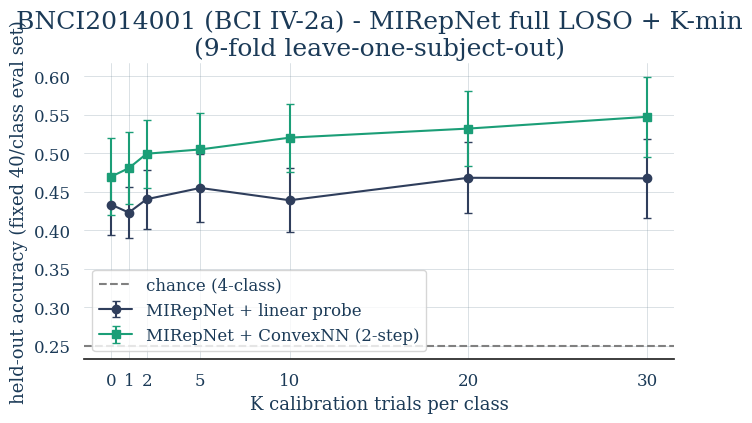

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.4))
ax.errorbar(lin_summary["k"], lin_summary["acc_mean"], yerr=lin_summary["sem"],
            marker="o", capsize=3, label="MIRepNet + linear probe")
ax.errorbar(summary["k"], summary["acc_mean"], yerr=summary["sem"],
            marker="s", capsize=3, label="MIRepNet + ConvexNN (2-step)")
ax.axhline(1.0 / N_CLASSES, ls="--", color="grey", label=f"chance ({N_CLASSES}-class)")
ax.set_xlabel("K calibration trials per class")
ax.set_ylabel(f"held-out accuracy (fixed {EVAL_PER_CLASS}/class eval set)")
ax.set_title(f"BNCI2014001 (BCI IV-2a) - MIRepNet full LOSO + K-min\n"
             f"({len(SUBJECTS)}-fold leave-one-subject-out)")
ax.set_xticks(list(K_BUDGETS))
ax.legend()
fig.tight_layout()
fig.show()

comparison = lin_summary[["k", "acc_mean", "sem", "n_subjects"]].rename(columns={"acc_mean": "linear_acc", "sem": "linear_sem"})
comparison = comparison.merge(
    summary[["k", "acc_mean", "sem"]].rename(columns={"acc_mean": "convex_acc", "sem": "convex_sem"}), on="k")
comparison


## 8. Save artifacts

In [9]:
out_dir = REPO_ROOT / "results" / "mirepnet_bnci2014001_kmin_nb"
out_dir.mkdir(parents=True, exist_ok=True)
stamp = time.strftime("%Y%m%d-%H%M%S")
lin_df.to_csv(out_dir / f"linear_per_split_{stamp}.csv", index=False)
lin_summary.to_csv(out_dir / f"linear_summary_{stamp}.csv", index=False)
df.to_csv(out_dir / f"convex_per_split_{stamp}.csv", index=False)
summary.to_csv(out_dir / f"convex_summary_{stamp}.csv", index=False)
comparison.to_csv(out_dir / f"comparison_{stamp}.csv", index=False)
print("wrote:", out_dir)
comparison


wrote: /Users/williamtan/Projects/cs229/etm_clf/results/mirepnet_bnci2014001_kmin_nb


,k,linear_acc,linear_sem,n_subjects,convex_acc,convex_sem
0,0,0.484722,0.047929,9,0.469444,0.049744
1,1,0.495833,0.052125,9,0.480556,0.046310
2,2,0.509722,0.051107,9,0.499306,0.044052
3,5,0.536806,0.057513,9,0.504861,0.047607
4,10,0.560417,0.053572,9,0.520139,0.044314
5,20,0.550694,0.050791,9,0.531944,0.048930
6,30,0.552778,0.050562,9,0.547222,0.052220
